# Water tank temperature measurements analysis

In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *

### Inputs

In [3]:
dataroot = '/Users/tlemaire/Documents/data/US_thermal_experiments'
datadir = os.path.join(dataroot, '20260904_tank')

### Load data

 2026/09/14 14:52:49: loading info from "/Users/tlemaire/Documents/data/US_thermal_experiments/20260904_tank" recording
 2026/09/14 14:52:49: getting sample rate from info.rhd header
 2026/09/14 14:52:49: sample rate: 20000.0 Hz
 2026/09/14 14:52:49: getting sample count and analog channel count from file sizes
 2026/09/14 14:52:49: sample count: 268600320, analog channel count: 1
 2026/09/14 14:52:49: loading analogin.dat as memmap
 2026/09/14 14:52:49: downsampling channel 0 from 20000.0 Hz to 119.760 Hz
 2026/09/14 14:52:50: converting downsampled ADC vector to volts
 2026/09/14 14:52:50: generating downsampled time vector
 2026/09/14 14:52:50: converting Osensa probe voltage to degC
 2026/09/14 14:52:50: Lowpass filtering temperature trace at 30 Hz
 2026/09/14 14:52:50: plotting longitudinal temperature recording at 3.992 Hz
 2026/09/14 14:52:51: loading digitalin.dat as memmap
 2026/09/14 14:52:51: no digitalin line specified, checking all lines for rising edges
 2026/09/14 14:52:

T (°C)                  timestamp  x (mm)  y (mm)  z (mm)  \
trial time (s)                                                                  
0     -0.491675  19.133748 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.483325  19.134786 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.474975  19.134078 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.466625  19.133043 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.458275  19.133724 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
...                    ...                        ...     ...     ...     ...   
3023   3.240775  17.200758 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.249125  17.200065 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.257475  17.200419 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.265825  17.201030 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.274175  17.200802 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   

                 Fdrive (MHz)  P (MPa)   Vpp (V)  tstim (s)  PRF (Hz)  DC (%)  \
trial time (s)                                                                  
0     -0.491675         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.483325         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.474975         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.466625         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.458275         2.095      0.0  0.000000        0.2     100.0    80.0   
...                       ...      ...       ...        ...       ...     ...   
3023   3.240775         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.249125         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.257475         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.265825         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.274175         2.095      0.8  0.257133        0.2     100.0    80.0   

                 elapsed time (s)  
trial time (s)                     
0     -0.491675          0.000000  
      -0.483325          0.000000  
      -0.474975          0.000000  
      -0.466625          0.000000  
      -0.458275          0.000000  
...                           ...  
3023   3.240775      12522.377839  
       3.249125      12522.377839  
       3.257475      12522.377839  
       3.265825      12522.377839  
       3.274175      12522.377839  

[1366848 rows x 12 columns]

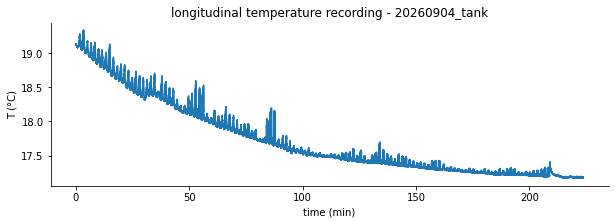

In [4]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadir, plot=True)

logger.info('processed experiment data:')
data

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [5]:
# Apply trial-by-trial linear detrending to the temperature data
logger.info('detrending temperature traces trial-by-trial')
data[f'detrended {TEMP_KEY}'] = (
    data
    .groupby('trial')
    [TEMP_KEY]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[REL_TEMP_KEY] = (
    data
    .groupby('trial')
    [f'detrended {TEMP_KEY}']
    .transform(compute_deltaT)
)

data

 2026/09/14 14:52:53: detrending temperature traces trial-by-trial


 2026/09/14 14:52:55: computing trial-by-trial relative temperature change


T (°C)                  timestamp  x (mm)  y (mm)  z (mm)  \
trial time (s)                                                                  
0     -0.491675  19.133748 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.483325  19.134786 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.474975  19.134078 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.466625  19.133043 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
      -0.458275  19.133724 2026-09-04 11:54:33.603206    -3.0     0.5     0.0   
...                    ...                        ...     ...     ...     ...   
3023   3.240775  17.200758 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.249125  17.200065 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.257475  17.200419 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.265825  17.201030 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   
       3.274175  17.200802 2026-09-04 15:23:15.981045    -3.0     0.5     5.0   

                 Fdrive (MHz)  P (MPa)   Vpp (V)  tstim (s)  PRF (Hz)  DC (%)  \
trial time (s)                                                                  
0     -0.491675         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.483325         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.474975         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.466625         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.458275         2.095      0.0  0.000000        0.2     100.0    80.0   
...                       ...      ...       ...        ...       ...     ...   
3023   3.240775         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.249125         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.257475         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.265825         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.274175         2.095      0.8  0.257133        0.2     100.0    80.0   

                 elapsed time (s)  detrended T (°C)   ΔT (°C)  
trial time (s)                                                 
0     -0.491675          0.000000         19.129290  0.000601  
      -0.483325          0.000000         19.130354  0.001665  
      -0.474975          0.000000         19.129672  0.000983  
      -0.466625          0.000000         19.128662 -0.000027  
      -0.458275          0.000000         19.129368  0.000679  
...                           ...               ...       ...  
3023   3.240775      12522.377839         17.201189 -0.000762  
       3.249125      12522.377839         17.200497 -0.001454  
       3.257475      12522.377839         17.200854 -0.001098  
       3.265825      12522.377839         17.201467 -0.000485  
       3.274175      12522.377839         17.201240 -0.000711  

[1366848 rows x 14 columns]

### Aggregate traces across trials for each condition 

In [6]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/14 14:52:57: computing trial-average data by ['x (mm)', 'y (mm)', 'z (mm)', 'P (MPa)']


ΔT (°C)     T (°C)   Vpp (V)  \
x (mm) y (mm) z (mm) P (MPa) time (s)                                   
-3.0   -0.5   0.0    0.0     -0.491675  0.000290  18.600318  0.000000   
                             -0.483325 -0.000093  18.599867  0.000000   
                             -0.474975 -0.000365  18.599527  0.000000   
                             -0.466625 -0.000160  18.599665  0.000000   
                             -0.458275  0.000136  18.599894  0.000000   
...                                          ...        ...       ...   
 3.0    0.5   5.0    0.8      3.240775 -0.000690  17.216207  0.257133   
                              3.249125 -0.000917  17.215986  0.257133   
                              3.257475 -0.001063  17.215845  0.257133   
                              3.265825 -0.000530  17.216384  0.257133   
                              3.274175  0.000515  17.217435  0.257133   

                                        detrended T (°C)  tstim (s)  DC (%)  \
x (mm) y (mm) z (mm) P (MPa) time (s)                                         
-3.0   -0.5   0.0    0.0     -0.491675         18.588531        0.2    80.0   
                             -0.483325         18.588148        0.2    80.0   
                             -0.474975         18.587876        0.2    80.0   
                             -0.466625         18.588081        0.2    80.0   
                             -0.458275         18.588377        0.2    80.0   
...                                                  ...        ...     ...   
 3.0    0.5   5.0    0.8      3.240775         17.214649        0.2    80.0   
                              3.249125         17.214422        0.2    80.0   
                              3.257475         17.214276        0.2    80.0   
                              3.265825         17.214809        0.2    80.0   
                              3.274175         17.215854        0.2    80.0   

                                        Fdrive (MHz)  PRF (Hz)  
x (mm) y (mm) z (mm) P (MPa) time (s)                           
-3.0   -0.5   0.0    0.0     -0.491675         2.095     100.0  
                             -0.483325         2.095     100.0  
                             -0.474975         2.095     100.0  
                             -0.466625         2.095     100.0  
                             -0.458275         2.095     100.0  
...                                              ...       ...  
 3.0    0.5   5.0    0.8      3.240775         2.095     100.0  
                              3.249125         2.095     100.0  
                              3.257475         2.095     100.0  
                              3.265825         2.095     100.0  
                              3.274175         2.095     100.0  

[170856 rows x 8 columns]

### Fit double exponential to temperature data

 2026/09/14 14:58:11: fitting double exponential to trial-averaged temperature traces
 2026/09/14 14:58:14: constructing fitted double exponential traces
 2026/09/14 14:58:15: plotting t0 distribution
 2026/09/14 14:58:15: plotting peak distribution
 2026/09/14 14:58:15: plotting tau_rise distribution
 2026/09/14 14:58:15: plotting tau_decay distribution
 2026/09/14 14:58:15: plotting offset distribution


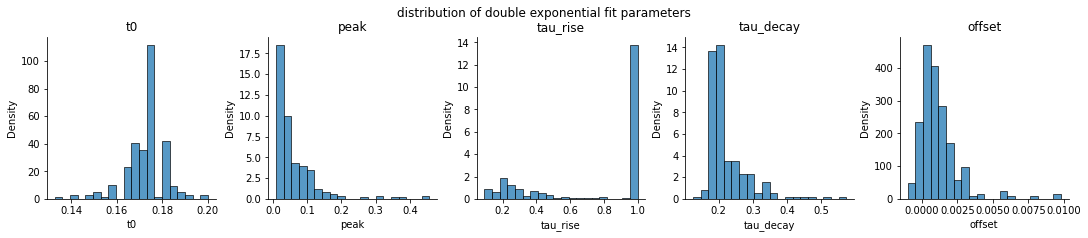

In [28]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = [k for k in aggdata.index.names if k != TIME_KEY]
groups = aggdata.groupby(gby)[REL_TEMP_KEY]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {REL_TEMP_KEY}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(TIME_KEY).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(TIME_KEY))
)

naxes = len(fits.columns)
fig, axes = plt.subplots(1, naxes, figsize=(3 * naxes, 3), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.histplot(
        fits[k],
        ax=ax,
        bins=20,
        stat='density',
    )
    ax.set_title(k)
    sns.despine(ax=ax)
    fig.suptitle('distribution of double exponential fit parameters', y=1.05)

### Plot stim-evoked temperature trace 

 2026/09/14 14:53:01: plotting stimulus-evoked temperature traces for y = -0.5 mm
 2026/09/14 14:53:08: plotting stimulus-evoked temperature traces for y = 0.0 mm
 2026/09/14 14:53:15: plotting stimulus-evoked temperature traces for y = 0.5 mm


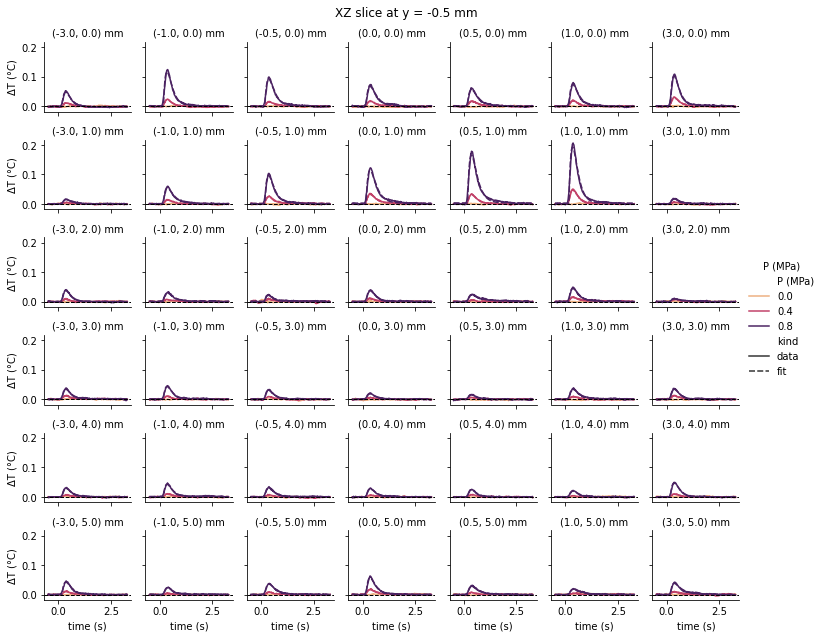

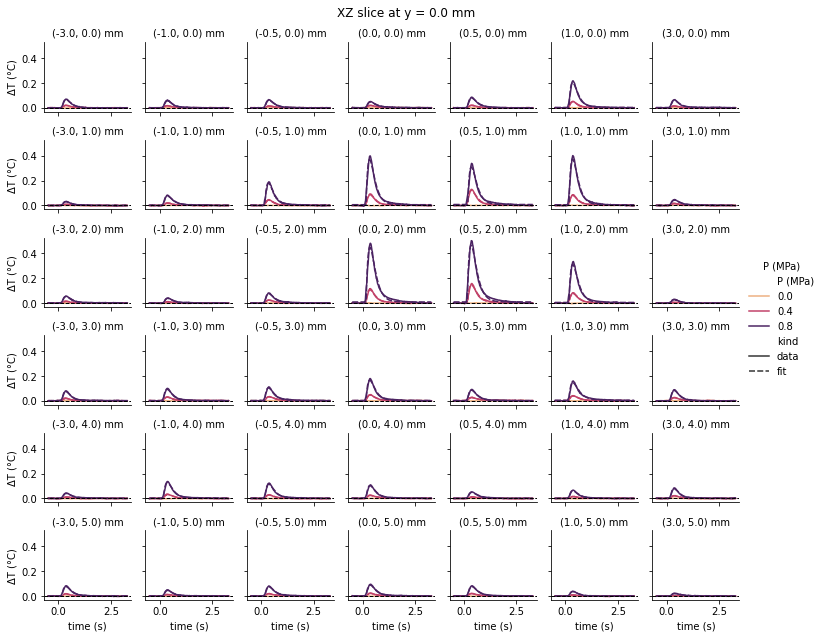

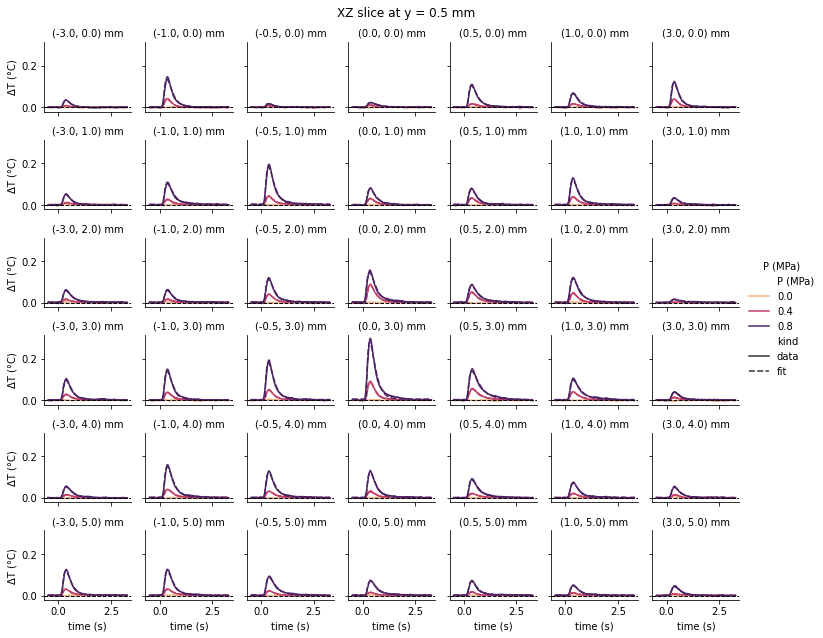

In [8]:
# Melt data by data/fit kind for plotting
ymap = {
    REL_TEMP_KEY: 'data',
    f'fitted {REL_TEMP_KEY}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure, with data and fitted traces distinguished by line style
hue = Label.P
for y, gdata in melted_data.groupby('y (mm)'):
    logger.info(f'plotting stimulus-evoked temperature traces for y = {y:.1f} mm')
    g = sns.FacetGrid(
        data=gdata.reset_index(),
        col='x (mm)',
        row='z (mm)',
        height=1.5,
    )
    g.fig.suptitle(f'XZ slice at y = {y:.1f} mm')
    g.set_titles(template='({col_name:.1f}, {row_name:.1f}) mm')
    g.map_dataframe(
        plot_evoked_thermal_response,
        y=REL_TEMP_KEY, 
        # errorbar=None,  # 'se'
        hue=hue,
        palette='flare',
        style='kind',
    )
    g.add_legend(title=hue)

### Compute max-evoked temperature change for each condition

In [9]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(data.columns)
logger.info('computing max-evoked temperature change for each condition and trial')
max_evoked_change = (
    data
    .groupby([*cond_keys, 'trial'])
    [REL_TEMP_KEY]
    .max()
    .rename(MAX_REL_TEMP_KEY)
)
max_evoked_change

logger.info('computing average max-evoked temperature change for each condition')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

 2026/09/14 14:53:36: computing max-evoked temperature change for each condition and trial
 2026/09/14 14:53:37: computing average max-evoked temperature change for each condition


### Plot heatmaps of max-evoked temperature change for each condition

 2026/09/14 15:34:40: plotting max-evoked ΔT (°C) for y = -0.5 mm, P = 0.0 MPa
 2026/09/14 15:34:40: plotting max-evoked ΔT (°C) for y = 0.0 mm, P = 0.0 MPa
 2026/09/14 15:34:40: plotting max-evoked ΔT (°C) for y = 0.5 mm, P = 0.0 MPa
 2026/09/14 15:34:40: plotting max-evoked ΔT (°C) for y = -0.5 mm, P = 0.4 MPa
 2026/09/14 15:34:40: plotting max-evoked ΔT (°C) for y = 0.0 mm, P = 0.4 MPa
 2026/09/14 15:34:41: plotting max-evoked ΔT (°C) for y = 0.5 mm, P = 0.4 MPa
 2026/09/14 15:34:41: plotting max-evoked ΔT (°C) for y = -0.5 mm, P = 0.8 MPa
 2026/09/14 15:34:41: plotting max-evoked ΔT (°C) for y = 0.0 mm, P = 0.8 MPa
 2026/09/14 15:34:41: plotting max-evoked ΔT (°C) for y = 0.5 mm, P = 0.8 MPa


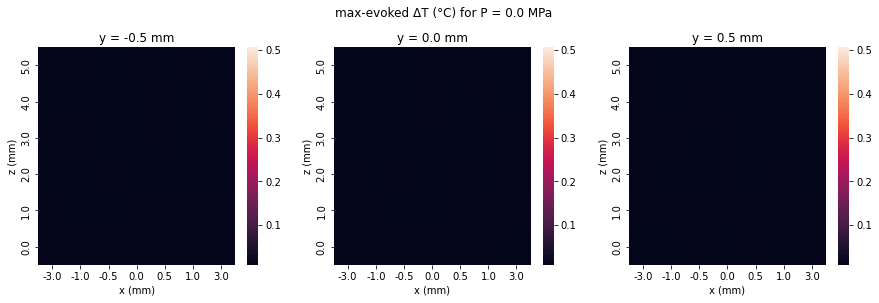

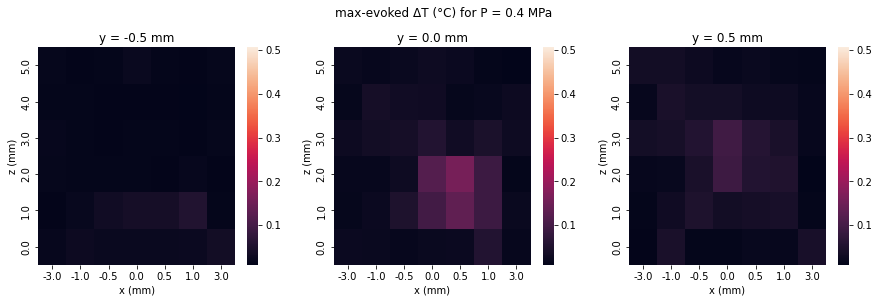

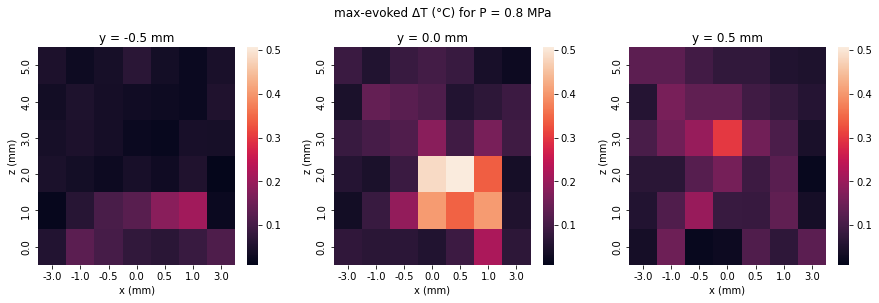

In [ ]:
vmin, vmax = agg_max_evoked_change.min(), agg_max_evoked_change.max()
gby = ['y (mm)', Label.P]
for P, gdata in agg_max_evoked_change.groupby(Label.P):
    naxes = len(gdata.index.get_level_values('y (mm)').unique())
    fig, axes = plt.subplots(1, naxes, figsize=(5 * naxes, 4), sharex=True)
    fig.suptitle(f'{MAX_REL_TEMP_KEY} for P = {P:.1f} MPa', y=1.02)
    for (y, gdata2), ax in zip(gdata.groupby('y (mm)'), axes):
        logger.info(f'plotting {MAX_REL_TEMP_KEY} for y = {y:.1f} mm, P = {P:.1f} MPa')
        ax.set_title(f'y = {y:.1f} mm')
        sns.heatmap(
            gdata2.droplevel(gby).unstack().T,
            ax=ax,
            vmin=vmin,
            vmax=vmax
        )
        ax.invert_yaxis()

### Plot dose-dependence of evoked temperature change at focus

 2026/09/14 15:34:53: focus identified at XYZ = (0.5, 0.0, 2.0) mm, max-evoked ΔT (°C) = 0.51
 2026/09/14 15:34:53: plotting pressure-dependent evoked temperature change traces
 2026/09/14 15:34:54: performing quadratic fit on max_ΔT vs pressure
 2026/09/14 15:34:54: plotting dose-dependence of max-evoked temperature change at focus


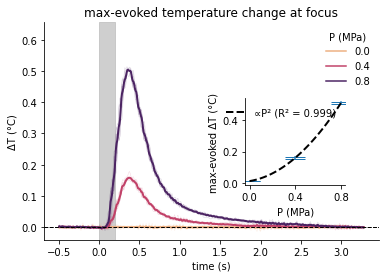

In [49]:
# Identify focus from trial-average max evoked temperature change at max pressure
maxP = data[Label.P].max()
focus_xyz = agg_max_evoked_change.loc[pd.IndexSlice[:, :, :, maxP]].idxmax()
focus_agg_max_evoked_change = agg_max_evoked_change.loc[tuple([*focus_xyz, maxP])]
logger.info(f'focus identified at XYZ = {focus_xyz} mm, {MAX_REL_TEMP_KEY} = {focus_agg_max_evoked_change:.2f}')

# Extract stats and data for the focus condition
focus_data, focus_max_evoked_change = select_subset(
    data, max_evoked_change, focus_xyz)

# Plot pressure dependence of temperature change at focus, with quadratic fit and R² value
fig = plot_pressure_dependence(
    focus_data, focus_max_evoked_change, title='max-evoked temperature change at focus')